In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import matplotlib.pyplot as plt

from src.preprocessing import (
    cargar_dataset_desde_api,
    limpiar_dataset,
    generar_resumen_calidad,
)

from src.visualizations import (
    graficar_mp25_por_comuna,
    graficar_mp25_por_region,
    graficar_evolucion_mp25,
    graficar_ranking_sensores,
    graficar_dispersion,
    graficar_correlaciones,
)

print("Importaciones correctas")

Importaciones correctas


# Análisis exploratorio de calidad del aire

Este notebook analiza las mediciones ambientales obtenidas desde la API del proyecto, revisando calidad de datos, distribución de contaminantes, evolución temporal y diferencias territoriales.

In [2]:
df_original = cargar_dataset_desde_api()
df = limpiar_dataset(df_original)

print(f"Filas originales: {len(df_original)}")
print(f"Filas procesadas: {len(df)}")
print(f"Columnas: {len(df.columns)}")

df.head()

Registros descargados: 1000
Registros descargados: 2000
Registros descargados: 3000
Registros descargados: 4000
Registros descargados: 5000
Registros descargados: 6000
Registros descargados: 7000
Registros descargados: 8000
Registros descargados: 9000
Registros descargados: 10000
Registros descargados: 11000
Registros descargados: 12000
Registros descargados: 13000
Registros descargados: 14000
Registros descargados: 15000
Registros descargados: 16000
Registros descargados: 17000
Registros descargados: 18000
Registros descargados: 19000
Registros descargados: 20000
Registros descargados: 21000
Registros descargados: 22000
Registros descargados: 23000
Registros descargados: 24000
Registros descargados: 25000
Registros descargados: 26000
Registros descargados: 26672
Filas originales: 26672
Filas procesadas: 26597
Columnas: 22


,fecha_hora,comuna,region,codigo_estacion,tipo_sensor,mp25,mp10,so2,no2,velocidad_viento,...,humedad,indice_vulnerabilidad_respiratoria,emision_maxima_permitida,categoria_ica,fecha,anio,mes,dia,hora,dia_semana
0,2026-06-01,Concepción,Biobío,SEN-CON-OF-001,publico_oficial,56.0,133.00,38.0,51.0,1.05,...,89.0,69.5,390.0,Regular,2026-06-01,2026,6,1,0,Monday
1,2026-06-01,Coronel,Biobío,SEN-COR-ONG-001,sensor_comunitario_ong,69.0,155.75,54.0,63.0,1.05,...,89.0,76.2,650.0,Regular,2026-06-01,2026,6,1,0,Monday
2,2026-06-01,Hualpén,Biobío,SEN-HUA-OF-001,publico_oficial,62.0,143.50,48.0,57.0,1.05,...,89.0,68.4,500.0,Regular,2026-06-01,2026,6,1,0,Monday
3,2026-06-01,Los Ángeles,Biobío,SEN-LAN-OF-001,publico_oficial,74.0,144.50,26.0,37.0,1.05,...,89.0,74.3,260.0,Regular,2026-06-01,2026,6,1,0,Monday
4,2026-06-01,Curicó,Maule,SEN-CUR-ONG-001,sensor_comunitario_ong,55.0,106.25,18.0,29.0,1.05,...,89.0,60.0,95.0,Regular,2026-06-01,2026,6,1,0,Monday


In [3]:
resumen_calidad = generar_resumen_calidad(df)
display(resumen_calidad)

,columna,tipo,nulos,porcentaje_nulos,valores_unicos
0,fecha_hora,datetime64[us],0,0.00,732
1,comuna,string,0,0.00,27
2,region,string,0,0.00,4
3,codigo_estacion,string,0,0.00,44
4,tipo_sensor,string,0,0.00,2
5,mp25,float64,0,0.00,1187
6,mp10,float64,0,0.00,9264
7,so2,float64,0,0.00,71
8,no2,float64,0,0.00,59
9,velocidad_viento,float64,0,0.00,126


In [4]:
print(f"Fecha inicial: {df['fecha_hora'].min()}")
print(f"Fecha final: {df['fecha_hora'].max()}")
print(f"Regiones: {df['region'].nunique()}")
print(f"Comunas: {df['comuna'].nunique()}")
print(f"Estaciones: {df['codigo_estacion'].nunique()}")

display(
    df["categoria_ica"]
    .value_counts(dropna=False)
    .rename_axis("categoria_ica")
    .reset_index(name="cantidad")
)

Fecha inicial: 2026-06-01 00:00:00
Fecha final: 2026-11-30 18:00:00
Regiones: 4
Comunas: 27
Estaciones: 44


,categoria_ica,cantidad
0,Buena,17682
1,Regular,6819
2,Alerta,1545
3,Preemergencia,536
4,Emergencia,15


In [5]:
variables_ambientales = [
    "mp25",
    "mp10",
    "so2",
    "no2",
    "velocidad_viento",
    "direccion_viento_grados",
    "temperatura",
    "humedad",
    "indice_vulnerabilidad_respiratoria",
    "emision_maxima_permitida",
]

variables_disponibles = [
    columna
    for columna in variables_ambientales
    if columna in df.columns
]

display(
    df[variables_disponibles]
    .describe()
    .transpose()
    .round(2)
)

,count,mean,std,min,25%,50%,75%,max
mp25,26597.0,45.61,23.46,9.00,29.90,37.40,60.75,178.05
mp10,26597.0,102.62,44.16,29.66,70.77,88.60,131.37,331.25
so2,26597.0,30.92,14.40,12.00,19.00,25.00,41.00,82.00
no2,26597.0,48.17,12.41,28.00,39.00,45.00,58.00,86.00
velocidad_viento,26597.0,3.16,1.61,0.35,1.86,2.69,4.55,6.37
direccion_viento_grados,26597.0,180.42,104.31,0.00,90.00,181.00,271.00,360.00
temperatura,26597.0,13.16,6.02,2.90,8.46,12.94,17.60,26.50
humedad,26597.0,72.28,16.69,38.00,61.00,76.00,84.00,98.00
indice_vulnerabilidad_respiratoria,26597.0,67.37,5.33,54.80,63.20,67.80,72.70,76.20
emision_maxima_permitida,24515.0,297.14,165.88,90.00,155.00,260.00,420.00,650.00


## Análisis territorial de MP2.5

Se comparan las concentraciones promedio de MP2.5 entre comunas y regiones para identificar las zonas con mayores niveles de contaminación.

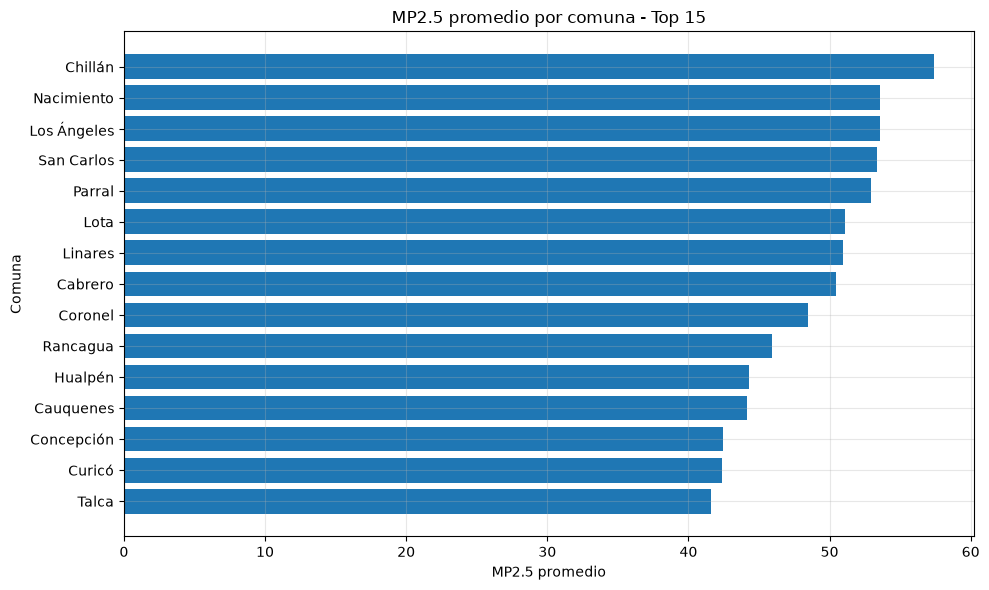

,comuna,region,mp25_promedio,mp25_maximo,cantidad_mediciones
4,Chillán,Ñuble,57.37,176.05,2134
16,Nacimiento,Biobío,53.60,172.05,673
12,Los Ángeles,Biobío,53.57,178.05,1766
20,San Carlos,Ñuble,53.38,171.05,1407
17,Parral,Maule,52.96,170.05,674
13,Lota,Biobío,51.07,125.05,674
11,Linares,Maule,50.93,168.05,1349
2,Cabrero,Biobío,50.45,167.05,674
8,Coronel,Biobío,48.49,126.05,1766
19,Rancagua,O'Higgins,45.93,118.05,2135


In [6]:
figura, ax = graficar_mp25_por_comuna(df, top_n=15)
plt.show()

ranking_comunas = (
    df.groupby(["comuna", "region"], as_index=False)
    .agg(
        mp25_promedio=("mp25", "mean"),
        mp25_maximo=("mp25", "max"),
        cantidad_mediciones=("mp25", "count"),
    )
    .sort_values("mp25_promedio", ascending=False)
)

display(ranking_comunas.head(10).round(2))

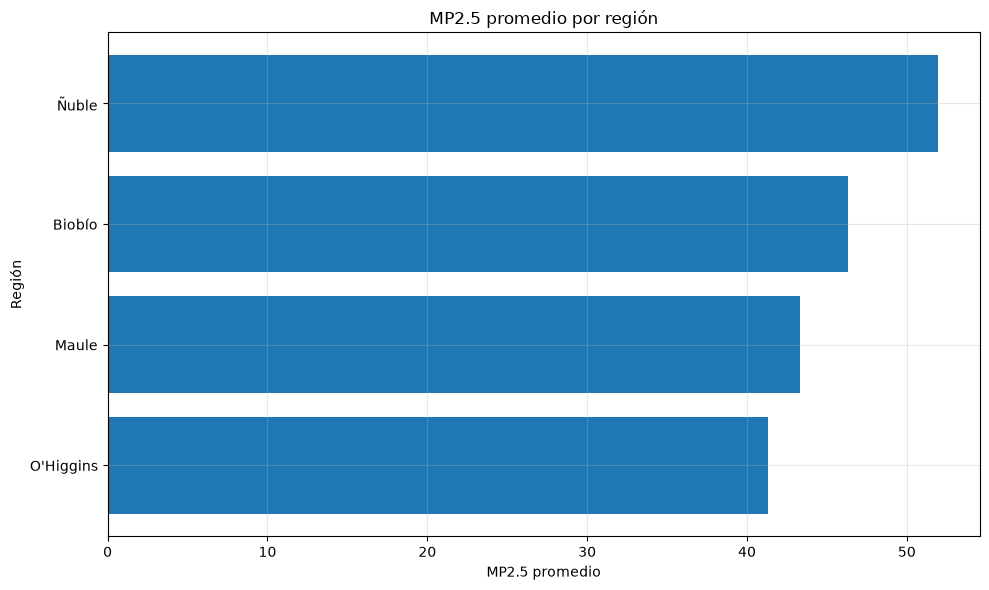

,region,mp25_promedio,mp25_maximo,cantidad_mediciones
3,Ñuble,51.98,176.05,4267
0,Biobío,46.33,178.05,10799
1,Maule,43.33,170.05,7268
2,O'Higgins,41.30,118.05,4263


In [7]:
figura, ax = graficar_mp25_por_region(df)
plt.show()

ranking_regiones = (
    df.groupby("region", as_index=False)
    .agg(
        mp25_promedio=("mp25", "mean"),
        mp25_maximo=("mp25", "max"),
        cantidad_mediciones=("mp25", "count"),
    )
    .sort_values("mp25_promedio", ascending=False)
)

display(ranking_regiones.round(2))

## Evolución temporal y días críticos

Se analiza cómo cambia el MP2.5 en el tiempo y se identifican las fechas con mayores concentraciones promedio.

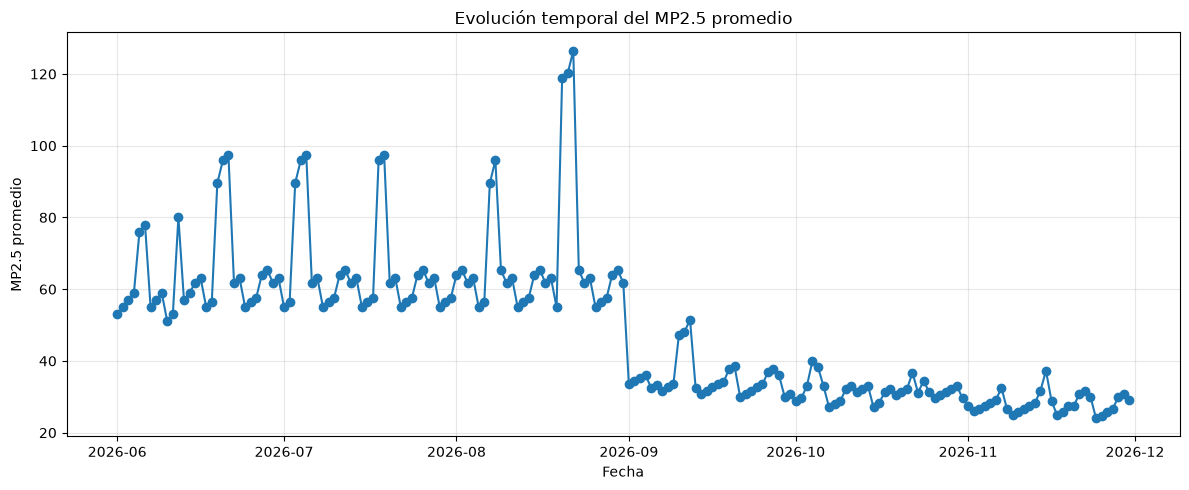

,fecha,mp25_promedio,mp25_maximo,cantidad_mediciones
82,2026-08-22,126.49,178.05,128
81,2026-08-21,120.14,171.70,128
80,2026-08-20,118.79,170.35,128
48,2026-07-19,97.28,133.40,128
20,2026-06-21,97.28,133.40,128
34,2026-07-05,97.28,133.40,128
33,2026-07-04,95.92,132.05,128
68,2026-08-08,95.92,132.05,128
47,2026-07-18,95.92,132.05,128
19,2026-06-20,95.92,132.05,128


In [8]:
figura, ax = graficar_evolucion_mp25(df, frecuencia="D")
plt.show()

dias_criticos = (
    df.groupby("fecha", as_index=False)
    .agg(
        mp25_promedio=("mp25", "mean"),
        mp25_maximo=("mp25", "max"),
        cantidad_mediciones=("mp25", "count"),
    )
    .sort_values("mp25_promedio", ascending=False)
)

display(dias_criticos.head(10).round(2))

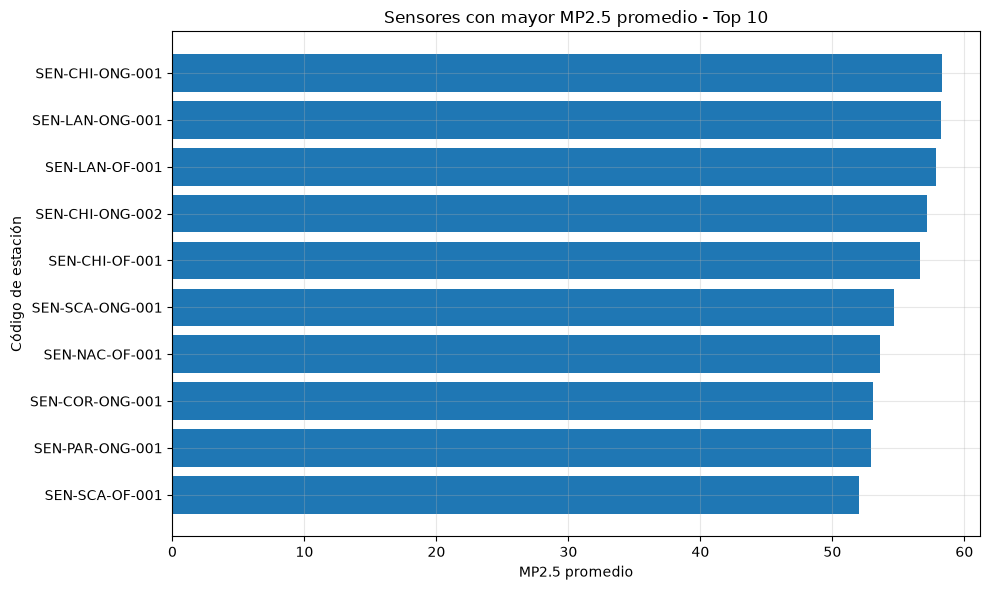

,codigo_estacion,comuna,tipo_sensor,mp25_promedio,mp25_maximo,cantidad_mediciones
5,SEN-CHI-ONG-001,Chillán,sensor_comunitario_ong,58.27,176.05,730
20,SEN-LAN-ONG-001,Los Ángeles,sensor_comunitario_ong,58.20,178.05,675
19,SEN-LAN-OF-001,Los Ángeles,publico_oficial,57.85,176.05,730
6,SEN-CHI-ONG-002,Chillán,sensor_comunitario_ong,57.15,176.05,674
4,SEN-CHI-OF-001,Chillán,publico_oficial,56.67,174.05,730
34,SEN-SCA-ONG-001,San Carlos,sensor_comunitario_ong,54.66,171.05,732
27,SEN-NAC-OF-001,Nacimiento,publico_oficial,53.60,172.05,673
12,SEN-COR-ONG-001,Coronel,sensor_comunitario_ong,53.04,126.05,732
28,SEN-PAR-ONG-001,Parral,sensor_comunitario_ong,52.96,170.05,674
33,SEN-SCA-OF-001,San Carlos,publico_oficial,52.00,169.05,675


In [9]:
figura, ax = graficar_ranking_sensores(df, top_n=10)
plt.show()

ranking_sensores = (
    df.groupby(
        ["codigo_estacion", "comuna", "tipo_sensor"],
        as_index=False,
    )
    .agg(
        mp25_promedio=("mp25", "mean"),
        mp25_maximo=("mp25", "max"),
        cantidad_mediciones=("mp25", "count"),
    )
    .sort_values("mp25_promedio", ascending=False)
)

display(ranking_sensores.head(10).round(2))

## Relación entre meteorología y contaminación

Se estudia la relación entre MP2.5 y variables meteorológicas como humedad, temperatura y velocidad del viento.

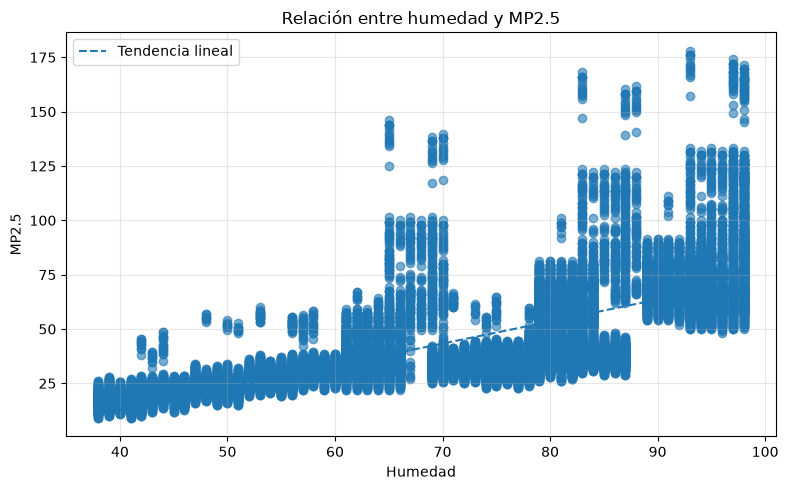

In [10]:
figura, ax = graficar_dispersion(
    df,
    variable_x="humedad",
    titulo="Relación entre humedad y MP2.5",
)
plt.show()

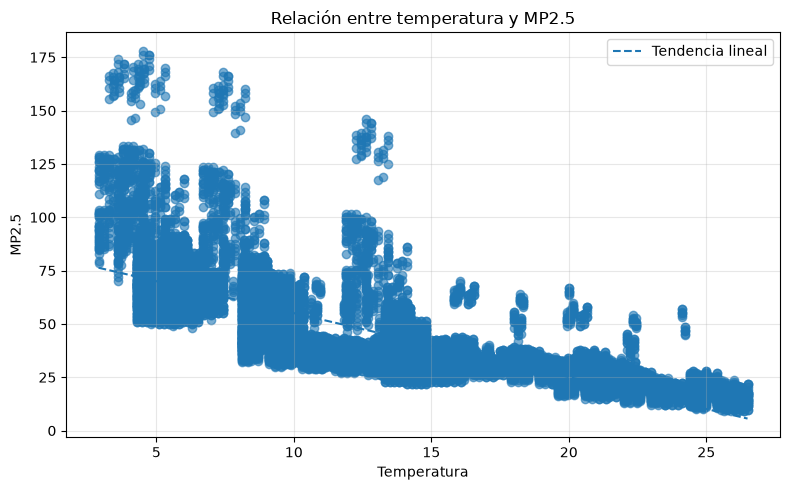

In [11]:
figura, ax = graficar_dispersion(
    df,
    variable_x="temperatura",
    titulo="Relación entre temperatura y MP2.5",
)
plt.show()

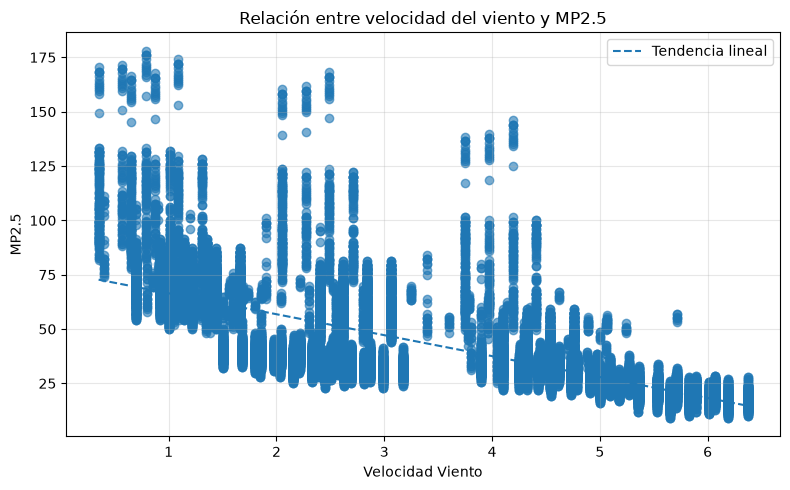

In [12]:
figura, ax = graficar_dispersion(
    df,
    variable_x="velocidad_viento",
    titulo="Relación entre velocidad del viento y MP2.5",
)
plt.show()

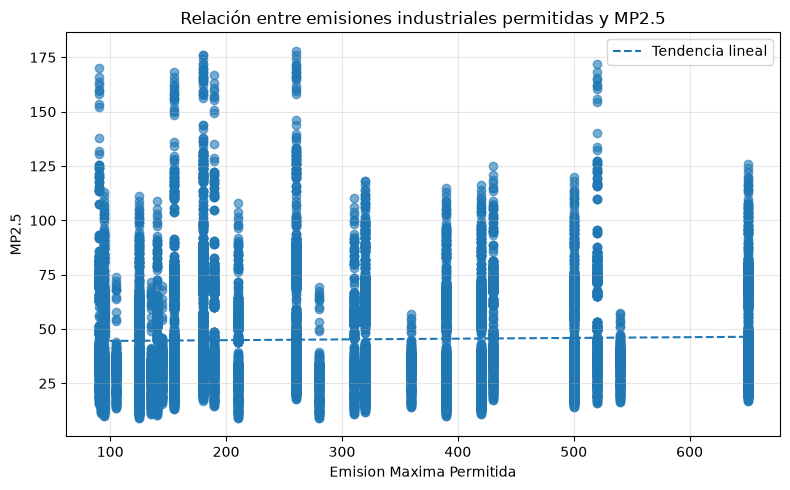

In [13]:
if (
    "emision_maxima_permitida" in df.columns
    and df["emision_maxima_permitida"].notna().any()
):
    figura, ax = graficar_dispersion(
        df,
        variable_x="emision_maxima_permitida",
        titulo="Relación entre emisiones industriales permitidas y MP2.5",
    )
    plt.show()
else:
    print(
        "No existen suficientes datos de emisiones industriales "
        "para generar este gráfico."
    )

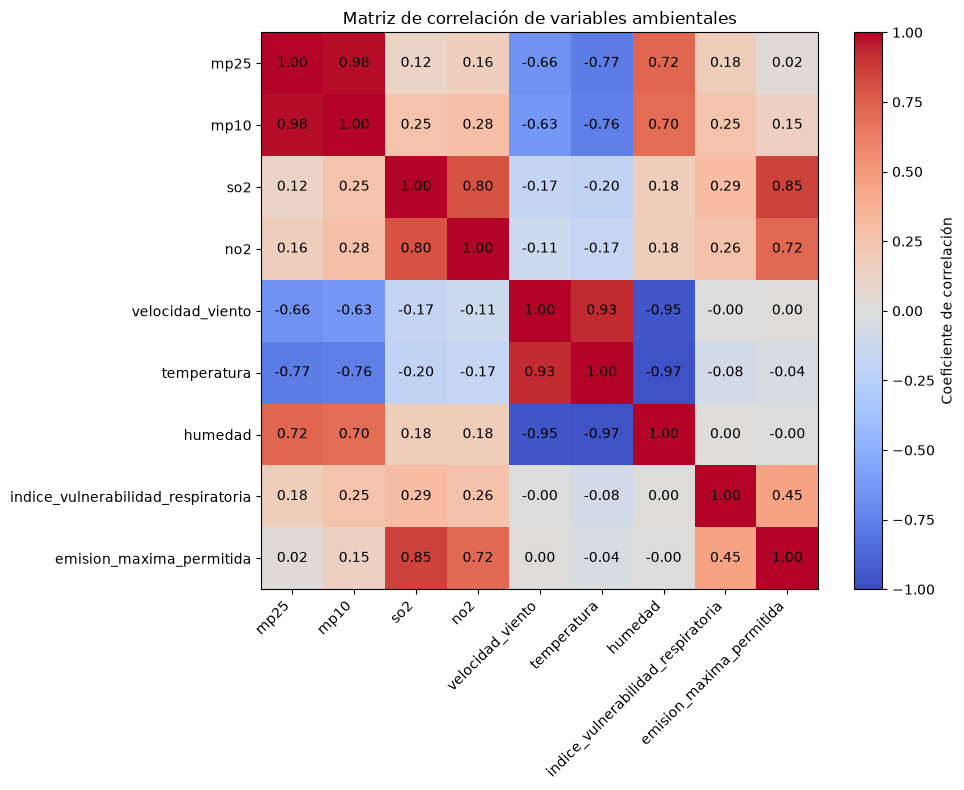

In [14]:
figura, ax = graficar_correlaciones(df)
plt.show()

## Conclusiones del análisis exploratorio

### Distribución territorial

Chillán presenta el mayor promedio de MP2.5, con 57.37, seguida por Nacimiento con 53.60 y Los Ángeles con 53.57. A nivel regional, Ñuble registra el promedio más alto con 51.98, seguido por Biobío con 46.33, Maule con 43.33 y O'Higgins con 41.30.

La cantidad de mediciones no es igual entre comunas y regiones, por lo que los promedios deben interpretarse considerando la cobertura disponible en cada territorio.

### Evolución temporal

Las concentraciones más altas se observan entre el 20 y el 22 de agosto de 2026. El 22 de agosto registra el mayor promedio diario de MP2.5, con 126.49, y un máximo de 178.05.

Desde septiembre se observa una disminución clara y sostenida de los niveles promedio. Este comportamiento es compatible con un componente estacional, aunque el periodo analizado, entre junio y noviembre, no permite evaluar un ciclo anual completo.

### Relaciones entre variables

MP2.5 y MP10 presentan una correlación muy alta de 0.98, lo que indica que ambos contaminantes varían de forma muy similar en el dataset.

MP2.5 presenta:

- correlación positiva con la humedad: 0.72;
- correlación negativa con la temperatura: -0.77;
- correlación negativa con la velocidad del viento: -0.66;
- relación débil con el índice de vulnerabilidad respiratoria: 0.18;
- relación prácticamente nula con la emisión máxima permitida: 0.02.

Las emisiones máximas permitidas muestran relaciones más fuertes con SO2, con 0.85, y NO2, con 0.72.

Las variables meteorológicas presentan correlaciones muy altas entre sí. La temperatura y la humedad alcanzan -0.97, la velocidad del viento y la humedad -0.95, y la velocidad del viento y la temperatura 0.93.

### Implicaciones para el clustering

No resulta conveniente utilizar simultáneamente todas las variables altamente correlacionadas, porque aportarían información redundante y podrían influir excesivamente en la formación de los clusters.

Para el modelado se deberán:

1. seleccionar variables representativas;
2. tratar los valores nulos;
3. estandarizar las escalas;
4. evaluar diferentes cantidades de clusters;
5. interpretar los grupos según contaminación, meteorología y vulnerabilidad.

Las correlaciones describen asociaciones dentro del dataset y no demuestran relaciones causales.